## Setup: imports, reproducibility, plotting config


In [1]:
# --- Imports ---
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import plotly
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_score, cross_val_predict,
                                     FixedThresholdClassifier)
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, balanced_accuracy_score,
                             brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance

import optuna

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Global plotting config ---
sns.set_theme(style='whitegrid')
pio.renderers.default = 'browser'   # interactive plotly figures open in the browser


# Part 1: Data Preparation
 This part loads the raw CSV, cleans/translates it, be used in part 2 (visuals) and 3 (training)

## Section A: import, translation, cleaning

In [2]:
df = pd.read_csv('mexico_covid19.csv')
translation_dict = {
    "FECHA_ARCHIVO": "report_date",
    "ID_REGISTRO": "registry_id",
    "ENTIDAD_UM": "medical_unit_state",
    "ENTIDAD_RES": "residence_state",
    "RESULTADO": "result", #RT-PCR test result
    "DELAY": "days_to_confirmation",
    "ENTIDAD_REGISTRO": "registration_state",
    "ENTIDAD": "state_name",
    "ABR_ENT": "state_abbreviation",
    "FECHA_ACTUALIZACION": "update_date",
    "ORIGEN": "origin",
    "SECTOR": "sector",
    "SEXO": "sex",
    "ENTIDAD_NAC": "birth_state",
    "MUNICIPIO_RES": "residence_municipality",
    "TIPO_PACIENTE": "patient_type",
    "FECHA_INGRESO": "admission_date",
    "FECHA_SINTOMAS": "symptoms_onset_date",
    "FECHA_DEF": "death_date",
    "INTUBADO": "intubated",
    "NEUMONIA": "pneumonia",
    "EDAD": "age",
    "NACIONALIDAD": "nationality",
    "EMBARAZO": "pregnant",
    "HABLA_LENGUA_INDIG": "speaks_indigenous_language",
    "DIABETES": "diabetes",
    "EPOC": "COPD",
    "ASMA": "asthma",
    "INMUSUPR": "immunosuppressed",
    "HIPERTENSION": "hypertension",
    "OTRA_COM": "other_comorbidity",
    "CARDIOVASCULAR": "cardiovascular",
    "OBESIDAD": "obesity",
    "RENAL_CRONICA": "chronic_renal_failure",
    "TABAQUISMO": "tobacco_use",
    "OTRO_CASO": "contact_with_other_case",
    "MIGRANTE": "migrant",
    "PAIS_NACIONALIDAD": "nationality_country",
    "PAIS_ORIGEN": "origin_country",
    "UCI": "ICU",
}
df = df.rename(columns=translation_dict)
df

,id,report_date,registry_id,medical_unit_state,residence_state,result,days_to_confirmation,registration_state,state_name,state_abbreviation,...,other_comorbidity,cardiovascular,obesity,chronic_renal_failure,tobacco_use,contact_with_other_case,migrant,nationality_country,origin_country,ICU
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,...,2,2,1,2,2,2,99,MÃ©xico,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,...,2,2,1,2,1,99,99,MÃ©xico,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,...,2,2,2,2,2,99,99,MÃ©xico,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,...,2,2,1,2,2,99,99,MÃ©xico,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,...,2,2,2,2,2,99,99,MÃ©xico,97,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263002,7094887,2020-06-03,1e019c,32,32,1,0,32,Zacatecas,ZS,...,2,2,2,2,2,1,99,MÃ©xico,99,97
263003,7053721,2020-06-03,1e2b05,12,12,1,0,12,Guerrero,GR,...,2,2,1,2,2,99,99,MÃ©xico,99,2
263004,7055429,2020-06-03,1e473f,20,20,1,0,20,Oaxaca,OC,...,2,2,2,1,2,99,99,MÃ©xico,99,2
263005,7043768,2020-06-03,1e6da1,13,13,1,0,13,Hidalgo,HG,...,2,2,2,2,2,2,99,MÃ©xico,99,2


In [3]:
# We don't translate municipios, we want a well generalized model which which does a prediction based on medicial information of the patient, not on where he/she lives

# YES/NO fields: 1=Yes, 2=No, 97=N/A, 98=Ignored, 99=Not specified — this comes from the SI_NO catalog
yes_no_map = {1: 'Yes', 2: 'No', 97: 'N/A', 98: 'Ignored', 99: 'Not specified'}
yes_no_cols = [
    'intubated', 'pneumonia', 'pregnant', 'speaks_indigenous_language',
    'diabetes', 'COPD', 'asthma', 'immunosuppressed', 'hypertension',
    'other_comorbidity', 'cardiovascular', 'obesity', 'chronic_renal_failure',
    'tobacco_use', 'contact_with_other_case', 'migrant', 'ICU',
]
for col in yes_no_cols:
    df[col] = df[col].map(yes_no_map)

# origin — this comes from the ORIGEN catalog
df['origin'] = df['origin'].map({1: 'USMER', 2: 'Outside USMER', 99: 'Not specified'})

# sector — this comes from the SECTOR catalog
df['sector'] = df['sector'].map({
    1: 'Red Cross', 2: 'DIF', 3: 'State', 4: 'IMSS', 5: 'IMSS-Bienestar',
    6: 'ISSSTE', 7: 'Municipal', 8: 'PEMEX', 9: 'Private',
    10: 'SEDENA (Army)', 11: 'SEMAR (Navy)', 12: 'SSA (Ministry of Health)',
    13: 'University', 99: 'Not specified',
})

# sex — SEXO catalog (1=Female, 2=Male),99 doesnt exist in the df
n_sex_99 = (df['sex'] == 99).sum()
print(f"{n_sex_99} rows with sex = 99 (not specified)")
df['sex'] = df['sex'].map({1: 0, 2: 1})


# patient_type — this comes from the TIPO_PACIENTE catalog
n_pat_99 = (df['patient_type'] == 99).sum()
print(f"{n_pat_99} rows with patient_type = 99 (not specified)")
df['patient_type'] = df['patient_type'].map({1: 'Outpatient', 2: 'Hospitalized'})

# nationality — NACIONALIDAD catalog (1=Mexican, 2=Foreign), 99 doesnt exist in the df
n_nat_99 = (df['nationality'] == 99).sum()
print(f"{n_nat_99} rows with nationality = 99 (not specified)")
df['nationality'] = df['nationality'].map({1: 0, 2: 1})


# result — this comes from the RESULTADO catalog
df['result'] = df['result'].map({
    1: 'Positive', 2: 'Negative'
})

# Mexican state codes (ENTIDAD_UM, ENTIDAD_RES, ENTIDAD_NAC, ENTIDAD_REGISTRO) — this comes from the ENTIDADES catalog
state_map = {
    1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur',
    4: 'Campeche', 5: 'Coahuila', 6: 'Colima', 7: 'Chiapas', 8: 'Chihuahua',
    9: 'Ciudad de México', 10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero',
    13: 'Hidalgo', 14: 'Jalisco', 15: 'Estado de México', 16: 'Michoacán',
    17: 'Morelos', 18: 'Nayarit', 19: 'Nuevo León', 20: 'Oaxaca',
    21: 'Puebla', 22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
    25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco', 28: 'Tamaulipas',
    29: 'Tlaxcala', 30: 'Veracruz', 31: 'Yucatán', 32: 'Zacatecas', 36:'Mexico',
    97: 'N/A', 98: 'Ignored', 99: 'Not specified',
}
for col in ['medical_unit_state', 'residence_state', 'birth_state', 'registration_state']:
    df[col] = df[col].map(state_map)

# Date columns — replace death_date sentinel then convert all to datetime
df['death_date'] = df['death_date'].replace('9999-99-99', None)

date_cols = ['report_date', 'update_date', 'admission_date', 'symptoms_onset_date', 'death_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

df

0 rows with sex = 99 (not specified)
0 rows with patient_type = 99 (not specified)
0 rows with nationality = 99 (not specified)


,id,report_date,registry_id,medical_unit_state,residence_state,result,days_to_confirmation,registration_state,state_name,state_abbreviation,...,other_comorbidity,cardiovascular,obesity,chronic_renal_failure,tobacco_use,contact_with_other_case,migrant,nationality_country,origin_country,ICU
0,9269,2020-04-12,00011f,Sinaloa,Sinaloa,Negative,0,Sinaloa,Sinaloa,SL,...,No,No,Yes,No,No,No,Not specified,MÃ©xico,97,N/A
1,33333,2020-04-12,00014e,Jalisco,Jalisco,Negative,0,Jalisco,Jalisco,JC,...,No,No,Yes,No,Yes,Not specified,Not specified,MÃ©xico,97,No
2,35483,2020-04-12,000153,Chihuahua,Chihuahua,Positive,0,Chihuahua,Chihuahua,CH,...,No,No,No,No,No,Not specified,Not specified,MÃ©xico,97,No
3,7062,2020-04-12,0001b6,Ciudad de México,Estado de México,Positive,0,Ciudad de México,Ciudad de Mexico,DF,...,No,No,Yes,No,No,Not specified,Not specified,MÃ©xico,97,N/A
4,23745,2020-04-12,0001c1,Ciudad de México,Ciudad de México,Negative,0,Ciudad de México,Ciudad de Mexico,DF,...,No,No,No,No,No,Not specified,Not specified,MÃ©xico,97,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263002,7094887,2020-06-03,1e019c,Zacatecas,Zacatecas,Positive,0,Zacatecas,Zacatecas,ZS,...,No,No,No,No,No,Yes,Not specified,MÃ©xico,99,N/A
263003,7053721,2020-06-03,1e2b05,Guerrero,Guerrero,Positive,0,Guerrero,Guerrero,GR,...,No,No,Yes,No,No,Not specified,Not specified,MÃ©xico,99,No
263004,7055429,2020-06-03,1e473f,Oaxaca,Oaxaca,Positive,0,Oaxaca,Oaxaca,OC,...,No,No,No,Yes,No,Not specified,Not specified,MÃ©xico,99,No
263005,7043768,2020-06-03,1e6da1,Hidalgo,Hidalgo,Positive,0,Hidalgo,Hidalgo,HG,...,No,No,No,No,No,No,Not specified,MÃ©xico,99,No


In [4]:
# check target distribution: hospitalized (1) vs outpatient (0)
df = df[df['patient_type'].isin(['Outpatient', 'Hospitalized'])].copy()
df['target'] = (df['patient_type'] == 'Hospitalized').astype(int)

print("\nClass distribution (0 = Outpatient, 1 = Hospitalized):")
print(df['target'].value_counts().sort_index())
print(f"Hospitalization prevalence: {df['target'].mean():.3f}")



Class distribution (0 = Outpatient, 1 = Hospitalized):
target
0    200838
1     62169
Name: count, dtype: int64
Hospitalization prevalence: 0.236


## Section B: Feature selection 

In [56]:
numeric_features = ['age']
comorbidity_cols = [
    'diabetes', 'COPD', 'asthma', 'immunosuppressed', 'hypertension',
    'other_comorbidity', 'cardiovascular', 'obesity', 'chronic_renal_failure',
    'tobacco_use',
]

binary_features = comorbidity_cols + ['pregnant', 'treated_in_residence_state', 'sex', 'nationality']

categorical_features = ['contact_with_other_case']

visualization_df = df.copy()

visualization_df['treated_in_residence_state'] = np.where(
    visualization_df['medical_unit_state'] == visualization_df['residence_state'], 'Yes', 'No')


visualization_df['died'] = visualization_df['death_date'].notna().astype(int)

binary_map = {'Yes': 1, 'No': 0}
for col in comorbidity_cols + ['pregnant', 'treated_in_residence_state']:
    visualization_df[col] = visualization_df[col].map(binary_map)


print(f"Number of empty pregnant columns {len(visualization_df[visualization_df['pregnant'].isna()])}")
print(f"Number of empty pregnant columns for males {len(visualization_df[(visualization_df['pregnant'].isna()) & (visualization_df["sex"] == 1)])}")

visualization_df['pregnant'] = np.where(visualization_df['sex'] == 1, 0, visualization_df['pregnant'])


# if we have no information we keep unkown as third category
visualization_df['contact_with_other_case'] = visualization_df['contact_with_other_case'].where(
    visualization_df['contact_with_other_case'].isin(['Yes', 'No']), 'Unknown')

visualization_df['N_COMORBIDITIES'] = visualization_df[comorbidity_cols].sum(axis=1).astype(int)
numeric_features = numeric_features + ['N_COMORBIDITIES']



# for the remaining columns if there is a null value we just drop the rows we dont lose a lot
drop_subset = comorbidity_cols + numeric_features + ['pregnant']
rows_before = len(visualization_df)
missing_per_col = visualization_df[drop_subset].isna().sum()
visualization_df = visualization_df.dropna(subset=drop_subset).reset_index(drop=True)
rows_after = len(visualization_df)
print(f"rows before dropping: {rows_before}")
print(f"rows after dropping: {rows_after}")
print(f"precentage dropped: {100*(1- rows_after/rows_before)}%")

Number of empty pregnant columns 134866
Number of empty pregnant columns for males 134310
rows before dropping: 263007
rows after dropping: 260424
precentage dropped: 0.9821031379392942%


In [57]:
visualization_df['pregnant'] = np.where(
    (visualization_df['sex'] == 1) | (visualization_df['pregnant'].isna()), 
    0, 
    visualization_df['pregnant']
)

In [79]:
# training_df leakage safe only usable features
feature_cols = numeric_features + binary_features + categorical_features

training_df = visualization_df[feature_cols + ['target']].copy()

X = training_df[feature_cols]
y = training_df['target']

print(f"Design matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Feature columns: {feature_cols}")
print("\nClass distribution after cleaning (0 = Outpatient, 1 = Hospitalized):")
print(df['target'].value_counts().sort_index())
print(f"Hospitalization prevalence: {df['target'].mean():.3f}")

Design matrix: 260,424 rows x 17 features
Feature columns: ['age', 'N_COMORBIDITIES', 'diabetes', 'COPD', 'asthma', 'immunosuppressed', 'hypertension', 'other_comorbidity', 'cardiovascular', 'obesity', 'chronic_renal_failure', 'tobacco_use', 'pregnant', 'treated_in_residence_state', 'sex', 'nationality', 'contact_with_other_case']

Class distribution after cleaning (0 = Outpatient, 1 = Hospitalized):
target
0    199375
1     61049
Name: count, dtype: int64
Hospitalization prevalence: 0.234


## PART 2 Visualizations

In [59]:
# Part 2 works on the full cleaned frame from Part 1
df = visualization_df


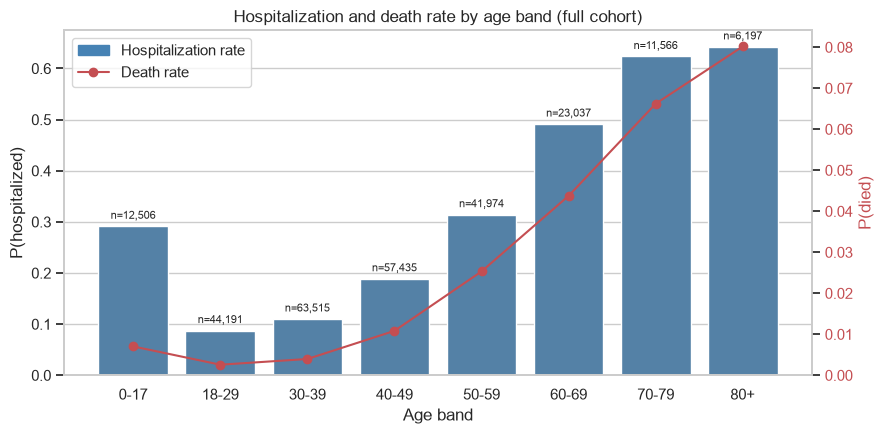

In [60]:
# EDA plot 1: hospitalization AND death rate by age band (full cohort)
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 120]
age_labels = ['0-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
tmp = df.assign(age_band=pd.cut(df['age'], bins=age_bins,
                                labels=age_labels, right=False))
by_age = tmp.groupby('age_band', observed=True).agg(
    hosp=('target', 'mean'), death=('died', 'mean'), size=('target', 'size'))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=by_age.index, y=by_age['hosp'], color='steelblue', ax=ax)
ax.set_title('Hospitalization and death rate by age band (full cohort)')
ax.set_xlabel('Age band'); ax.set_ylabel('P(hospitalized)')
for i, (m, n) in enumerate(zip(by_age['hosp'], by_age['size'])):
    ax.text(i, m + 0.01, f'n={n:,}', ha='center', va='bottom', fontsize=8)

# Death rate overlaid on a secondary axis.
ax2 = ax.twinx()
ax2.plot(range(len(by_age)), by_age['death'], 'o-', color='#C44E52')
ax2.set_ylabel('P(died)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.set_ylim(bottom=0); ax2.grid(False)

ax.legend(handles=[Patch(color='steelblue', label='Hospitalization rate'),
                   Line2D([0], [0], color='#C44E52', marker='o', label='Death rate')],
          loc='upper left')
plt.tight_layout(); plt.show()

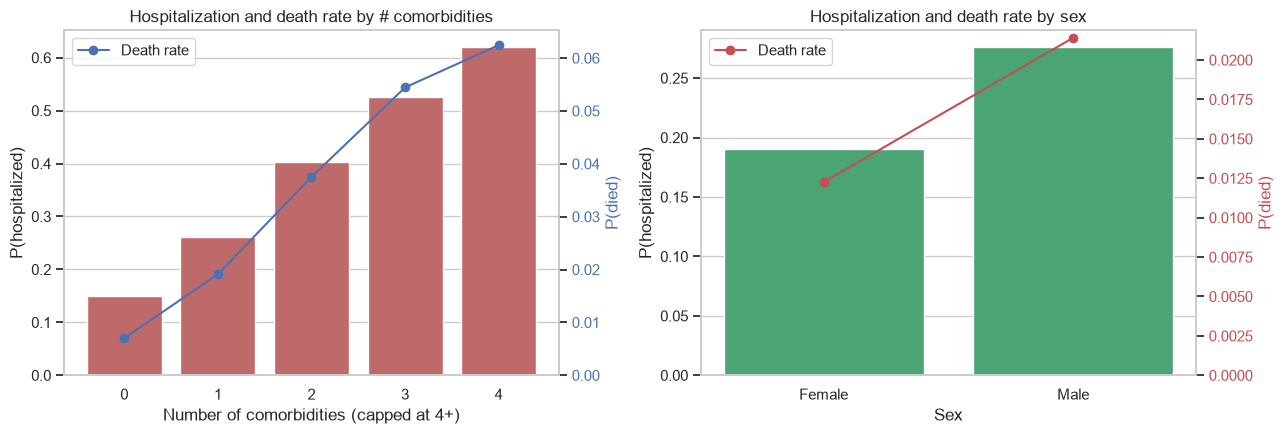

In [61]:
# EDA plot 2: hospitalization AND death rate by comorbidity burden and by sex 

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: by number of comorbidities ---
n_comorb = df[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4)
comorb_df = pd.DataFrame({'n_comorb': n_comorb.astype(int),
                          'target': df['target'], 'died': df['died']})
by_comorb = comorb_df.groupby('n_comorb').agg(hosp=('target', 'mean'), death=('died', 'mean'))
sns.barplot(x=by_comorb.index, y=by_comorb['hosp'], color='indianred', ax=axes[0])
axes[0].set_title('Hospitalization and death rate by # comorbidities')
axes[0].set_xlabel('Number of comorbidities (capped at 4+)')
axes[0].set_ylabel('P(hospitalized)')
ax0b = axes[0].twinx()
ax0b.plot(range(len(by_comorb)), by_comorb['death'], 'o-', color='#4C72B0')
ax0b.set_ylabel('P(died)', color='#4C72B0')
ax0b.tick_params(axis='y', labelcolor='#4C72B0')
ax0b.set_ylim(bottom=0); ax0b.grid(False)
axes[0].legend(handles=[Line2D([0], [0], color='#4C72B0', marker='o', label='Death rate')],
               loc='upper left')

# --- Right: by sex ---
by_sex = df.groupby('sex').agg(hosp=('target', 'mean'),
                               death=('died', 'mean')).sort_values('hosp')
by_sex = by_sex.rename(index={0: 'Female', 1: 'Male'})
sns.barplot(x=by_sex.index, y=by_sex['hosp'], color='mediumseagreen', ax=axes[1])
axes[1].set_title('Hospitalization and death rate by sex')
axes[1].set_xlabel('Sex'); axes[1].set_ylabel('P(hospitalized)')
ax1b = axes[1].twinx()
ax1b.plot(range(len(by_sex)), by_sex['death'], 'o-', color='#C44E52')
ax1b.set_ylabel('P(died)', color='#C44E52')
ax1b.tick_params(axis='y', labelcolor='#C44E52')
ax1b.set_ylim(bottom=0); ax1b.grid(False)
axes[1].legend(handles=[Line2D([0], [0], color='#C44E52', marker='o', label='Death rate')],
               loc='upper left')

plt.tight_layout(); plt.show()

In [62]:
# EDA plot 3: KMeans clustering on [age, sex, #comorbidities].
# Two interactive 3D scatters side by side, opened in the browser:
# left coloured by KMeans cluster, right coloured by hospitalization outcome.


clust = pd.DataFrame({
    'age': df['age'],
    'sex': df['sex'],  
    'n_comorbidities': df[comorbidity_cols].sum(axis=1),
    'target': df['target'],
}).reset_index(drop=True)

# Cluster on age, sex and comorbidity count 
cluster_features = ['age', 'sex', 'n_comorbidities']
Z = StandardScaler().fit_transform(clust[cluster_features])
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
clust['cluster'] = kmeans.fit_predict(Z).astype(str)
clust['outcome'] = np.where(clust['target'] == 1, 'Hospitalized', 'Outpatient')

# Sample + jitter the discrete axes (sex is 0/1, comorbidity count is an integer) for readability
rng = np.random.RandomState(RANDOM_STATE)
sample = rng.choice(len(clust), size=min(5000, len(clust)), replace=False)
plot_df = clust.iloc[sample].copy()
plot_df['sex_jit'] = plot_df['sex'] + rng.uniform(-0.08, 0.08, len(plot_df))
plot_df['comorbidities_jit'] = plot_df['n_comorbidities'] + rng.uniform(-0.25, 0.25, len(plot_df))

CLUSTER_COLORS = {'0': '#2a78d6', '1': '#1baf7a', '2': '#eda100', '3': '#008300'}
OUTCOME_COLORS = {'Outpatient': '#2a78d6', 'Hospitalized': '#e34948'}

fig = make_subplots(
    rows=1, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=('Coloured by KMeans cluster', 'Coloured by hospitalization outcome'),
)

for c, colour in CLUSTER_COLORS.items():
    sub = plot_df[plot_df['cluster'] == c]
    fig.add_trace(go.Scatter3d(
        x=sub['age'], y=sub['comorbidities_jit'], z=sub['sex_jit'],
        mode='markers', name=f'Cluster {c}',
        legendgroup='cluster', legendgrouptitle_text='Cluster',
        marker=dict(size=3, color=colour, opacity=0.6),
    ), row=1, col=1)

for outcome, colour in OUTCOME_COLORS.items():
    sub = plot_df[plot_df['outcome'] == outcome]
    fig.add_trace(go.Scatter3d(
        x=sub['age'], y=sub['comorbidities_jit'], z=sub['sex_jit'],
        mode='markers', name=outcome,
        legendgroup='outcome', legendgrouptitle_text='Outcome',
        marker=dict(size=3, color=colour, opacity=0.6),
    ), row=1, col=2)

fig.update_scenes(xaxis_title='Age', yaxis_title='# comorbidities',
                  zaxis_title='Sex (0 = Female, 1 = Male)')
fig.update_layout(
    title='Patient clusters on [age, sex, # comorbidities] vs. hospitalization outcome',
    height=750, width=1500,
)
fig.show()

# Cluster profiles: how the clusters differ, and their hospitalization rate
profile = clust.groupby('cluster').agg(
    n=('target', 'size'),
    mean_age=('age', 'mean'),
    share_male=('sex', 'mean'),
    mean_comorbidities=('n_comorbidities', 'mean'),
    hospitalization_rate=('target', 'mean'),
).round(2)
print("Cluster profiles:")
print(profile)

Cluster profiles:
              n  mean_age  share_male  mean_comorbidities  \
cluster                                                     
0         75247     31.69        1.00                0.29   
1        103063     37.59        0.00                0.32   
2         49856     58.47        0.99                0.92   
3         32258     59.09        0.27                2.64   

         hospitalization_rate  
cluster                        
0                        0.15  
1                        0.13  
2                        0.42  
3                        0.49  


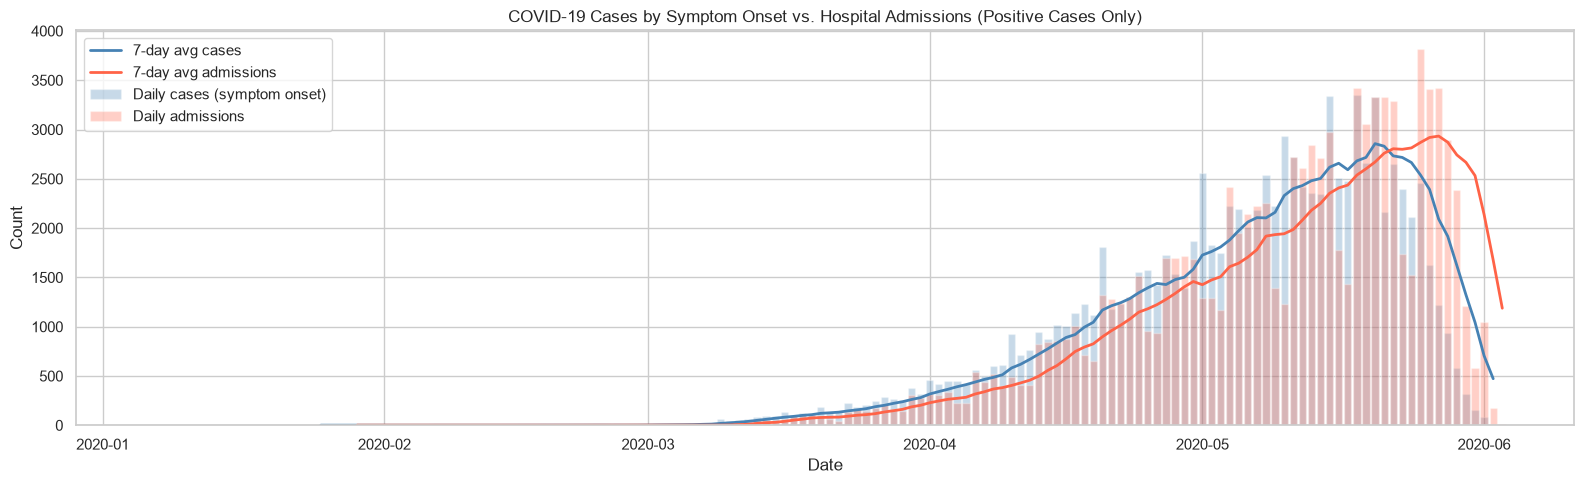

In [63]:
# EDA plot 4: dataset-level time series — daily positive cases vs. hospital admissions
positives = df[df['result'] == 'Positive']

daily_cases = (
    positives
    .groupby('symptoms_onset_date')
    .size()
    .rename('new_cases')
    
    .sort_index()
)
rolling_avg = daily_cases.rolling(window=7).mean()

daily_admissions = (
    positives
    .groupby('admission_date')
    .size()
    .rename('admissions')
    .sort_index()
)
rolling_avg_adm = daily_admissions.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(daily_cases.index, daily_cases, color='steelblue', alpha=0.3, label='Daily cases (symptom onset)')
ax.plot(rolling_avg.index, rolling_avg, color='steelblue', linewidth=2, label='7-day avg cases')

ax.bar(daily_admissions.index, daily_admissions, color='tomato', alpha=0.3, label='Daily admissions')
ax.plot(rolling_avg_adm.index, rolling_avg_adm, color='tomato', linewidth=2, label='7-day avg admissions')

ax.set_title('COVID-19 Cases by Symptom Onset vs. Hospital Admissions (Positive Cases Only)')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## Part 3: Model Training & Evaluation


In [64]:
# Part 3 trains on the leakage-safe modelling frame from Part 1
df = training_df


## Section A: Define Utils for model comparison 

In [65]:
# We fix the train/test split before comparing any models to keep the evaluation fair

train_idx, test_idx = train_test_split(
    df.index.to_numpy(),
    test_size=0.20,
    stratify=y, # to keep the test and train set with the same hospitalization rate
    random_state=RANDOM_STATE,
)

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
train_df = df.loc[train_idx]   

In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # same split everywhere


def make_preprocessor():
    """Preprocessing shared by every model. has to be done fore every fold to prevent leakage with the scaling"""
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

## Section B: Model Comparison

In [67]:
# we do gird search for hyperparameters we only do a search over the most impactful ones

scoring = ['roc_auc', 'average_precision', 'f1', 'recall']

models = {
    'Dummy (prior)':        (DummyClassifier(strategy='prior'), {}),
    'Logistic Regression':  (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                             {'clf__C': [0.1, 1, 10],
                              'clf__class_weight': [None, 'balanced']}),
    'Random Forest':        (RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                    random_state=RANDOM_STATE),
                             {'clf__max_depth': [10, 20, None],
                              'clf__min_samples_leaf': [1, 5],
                              'clf__max_features': ['sqrt', None]}),
    'Neural Network (MLP)': (MLPClassifier(early_stopping=True, max_iter=200,
                                           random_state=RANDOM_STATE),
                             {'clf__hidden_layer_sizes': [(32,), (64,), (128,)],
                              'clf__alpha': [1e-4, 1e-3],
                              'clf__learning_rate_init': [1e-3, 1e-2]}),
}

rows = []
for name, (clf, grid) in models.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', clf)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring=scoring, refit='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    i = gs.best_index_   
    rows.append({
        'model':       name,
        'best_params': gs.best_params_,
        'ROC_AUC':     gs.cv_results_['mean_test_roc_auc'][i],
        'PR_AUC':      gs.cv_results_['mean_test_average_precision'][i],
        'F1':          gs.cv_results_['mean_test_f1'][i],
        'Recall':      gs.cv_results_['mean_test_recall'][i],
    })

results = pd.DataFrame(rows).set_index('model').round(4)
results

,best_params,ROC_AUC,PR_AUC,F1,Recall
model,,,,,
Dummy (prior),{},0.5000,0.2344,0.0000,0.0000
Logistic Regression,"{'clf__C': 1, 'clf__class_weight': 'balanced'}",0.7947,0.5668,0.5553,0.7289
Random Forest,"{'clf__max_depth': 20, 'clf__max_features': 's...",0.8212,0.6105,0.5230,0.4280
Neural Network (MLP),"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes...",0.8232,0.6156,0.5243,0.4281


## Section C: Hyperparameter Search and Cross-Validation 

In [68]:
N_TRIALS = 30


def make_mlp(trial):
    """Build an MLPClassifier from an Optuna trial (also works with a FixedTrial for the refit)."""
    n_layers = trial.suggest_int('n_layers', 1, 2)
    hidden = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256, log=True)
                   for i in range(n_layers))
    return MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
        learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        batch_size=trial.suggest_categorical('batch_size', [128, 256, 512]),
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        max_iter=200, random_state=RANDOM_STATE,
    )


def objective(trial):
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', make_mlp(trial))])
    return cross_val_score(pipe, X_train, y_train, cv=cv,
                           scoring='roc_auc', n_jobs=-1).mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)   # keep the notebook output readable
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Trials: {len(study.trials)}  |  Total CV fits: {len(study.trials) * cv.get_n_splits()}")
print(f"\nBest CV ROC-AUC within training on validation: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k} = {v}")

# Refit the best configuration on the full training set
best_model = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', make_mlp(optuna.trial.FixedTrial(study.best_params))),
]).fit(X_train, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

Trials: 30  |  Total CV fits: 150

Best CV ROC-AUC within training on validation: 0.8235
Best hyperparameters:
  n_layers = 2
  n_units_l0 = 49
  n_units_l1 = 247
  alpha = 6.3238489915345e-06
  learning_rate_init = 0.0002859997907407981
  batch_size = 512


In [69]:
# # For development
# best_params = {
#     'n_layers': 1,
#     'n_units_l0': 176,
#     'alpha': 0.0004218279954930134,
#     'learning_rate_init': 0.001563469271718208,
#     'batch_size': 512,
# }
# 
# hidden = tuple(best_params[f'n_units_l{i}'] for i in range(best_params['n_layers']))
# 
# best_model = Pipeline([
#     ('prep', make_preprocessor()),
#     ('clf', MLPClassifier(
#         hidden_layer_sizes=hidden,
#         alpha=best_params['alpha'],
#         learning_rate_init=best_params['learning_rate_init'],
#         batch_size=best_params['batch_size'],
#         early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
#         max_iter=200, random_state=RANDOM_STATE,
#     )),
# ]).fit(X_train, y_train)
# 
# print("best_model trained on the full training set with the fixed best hyperparameters.")

## Section D: Classification threshold calculation and evaluation of its impact

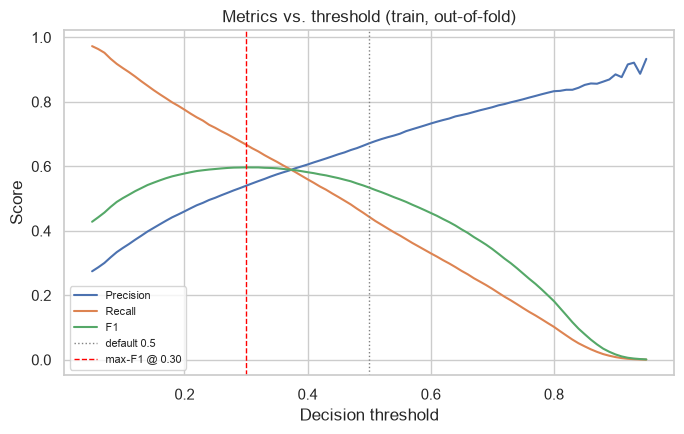

Operating threshold chosen on training OOF data: 0.30  (precision=0.540, recall=0.667, F1=0.597)


In [70]:
thresholds = np.linspace(0.05, 0.95, 91)
oof_proba = cross_val_predict(clone(best_model), X_train, y_train,
                              cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    prec_t.append(precision_score(y_train, pred_t, zero_division=0))
    rec_t.append(recall_score(y_train, pred_t, zero_division=0))
    f1_t.append(f1_score(y_train, pred_t, zero_division=0))
best_t_train = float(thresholds[int(np.argmax(f1_t))])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, prec_t, label="Precision")
ax.plot(thresholds, rec_t, label="Recall")
ax.plot(thresholds, f1_t, label="F1")
ax.axvline(0.5, color='grey', ls=':', lw=1, label="default 0.5")
ax.axvline(best_t_train, color='red', ls='--', lw=1, label=f"max-F1 @ {best_t_train:.2f}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs. threshold (train, out-of-fold)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

CHOSEN_THRESHOLD = best_t_train   
pred_bt = (oof_proba >= best_t_train).astype(int)
print(f"Operating threshold chosen on training OOF data: {CHOSEN_THRESHOLD:.2f}  "
      f"(precision={precision_score(y_train, pred_bt, zero_division=0):.3f}, "
      f"recall={recall_score(y_train, pred_bt, zero_division=0):.3f}, "
      f"F1={f1_score(y_train, pred_bt, zero_division=0):.3f})")

In [71]:
# add calculated threshold to model

final_model = FixedThresholdClassifier(
    FrozenEstimator(best_model), threshold=CHOSEN_THRESHOLD,
).fit(X_train, y_train)

 Cross-validated training performance
Threshold-free metrics:
ROC-AUC                0.823
PR-AUC                 0.616
Brier score            0.130

Threshold-dependent metrics: chosen threshold 0.30 vs. default 0.50
                      @ 0.30    @ 0.50
F1                     0.597     0.534
Precision              0.540     0.671
Recall                 0.667     0.443
Balanced accuracy      0.747     0.688


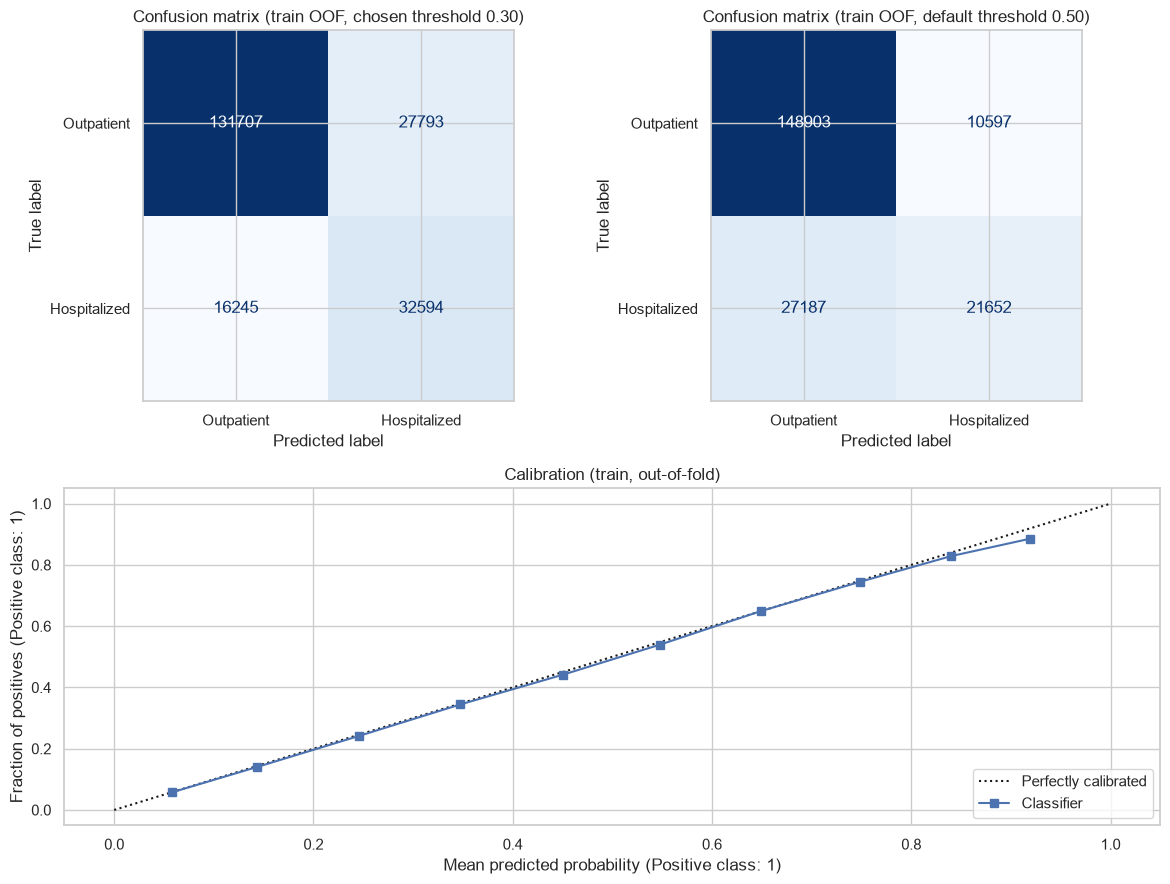

In [72]:
# confusion matrix with default and calculated threshold
oof_pred = (oof_proba >= CHOSEN_THRESHOLD).astype(int)
oof_pred_05 = (oof_proba >= 0.5).astype(int)

print(" Cross-validated training performance")
print("Threshold-free metrics:")
print(f"{'ROC-AUC':18s}{roc_auc_score(y_train, oof_proba):>10.3f}")
print(f"{'PR-AUC':18s}{average_precision_score(y_train, oof_proba):>10.3f}")
print(f"{'Brier score':18s}{brier_score_loss(y_train, oof_proba):>10.3f}")

print(f"\nThreshold-dependent metrics: chosen threshold {CHOSEN_THRESHOLD:.2f} vs. default 0.50")
print(f"{'':18s}{'@ ' + format(CHOSEN_THRESHOLD, '.2f'):>10s}{'@ 0.50':>10s}")
print(f"{'F1':18s}{f1_score(y_train, oof_pred):>10.3f}{f1_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Precision':18s}{precision_score(y_train, oof_pred):>10.3f}{precision_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Recall':18s}{recall_score(y_train, oof_pred):>10.3f}{recall_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Balanced accuracy':18s}{balanced_accuracy_score(y_train, oof_pred):>10.3f}{balanced_accuracy_score(y_train, oof_pred_05):>10.3f}")

fig, axes = plt.subplot_mosaic([['cm_chosen', 'cm_05'], ['cal', 'cal']],
                               figsize=(12, 9), height_ratios=[1.1, 1])
ConfusionMatrixDisplay(
    confusion_matrix(y_train, oof_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes['cm_chosen'], colorbar=False, cmap='Blues', values_format='d')
axes['cm_chosen'].set_title(f'Confusion matrix (train OOF, chosen threshold {CHOSEN_THRESHOLD:.2f})')
ConfusionMatrixDisplay(
    confusion_matrix(y_train, oof_pred_05),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes['cm_05'], colorbar=False, cmap='Blues', values_format='d')
axes['cm_05'].set_title('Confusion matrix (train OOF, default threshold 0.50)')
CalibrationDisplay.from_predictions(y_train, oof_proba, n_bins=10, ax=axes['cal'])
axes['cal'].set_title('Calibration (train, out-of-fold)')
plt.tight_layout(); plt.show()

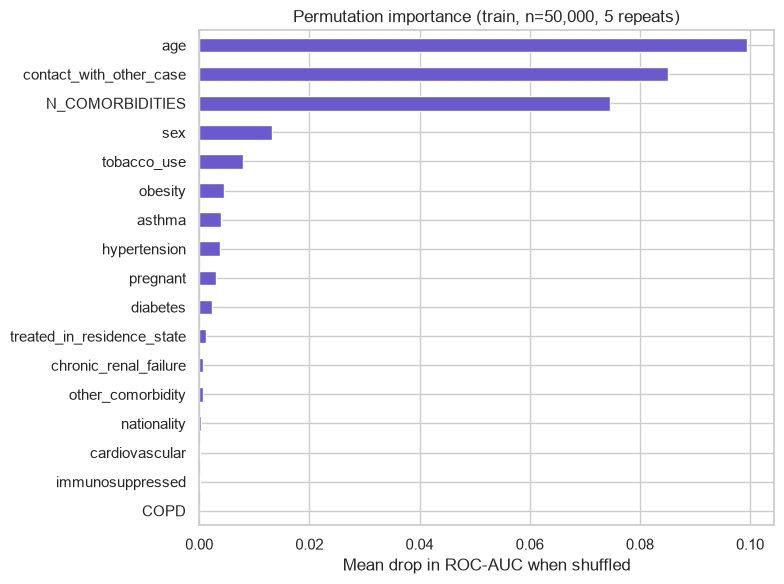

In [73]:
# was used to evaluate different parameters to add or remove 

rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(50000, len(X_train))
sub = rng.choice(len(X_train), size=n_pi, replace=False)
pi_train = permutation_importance(best_model, X_train.iloc[sub], y_train.iloc[sub],
                                  scoring='roc_auc', n_repeats=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
imp_train = (pd.Series(pi_train.importances_mean, index=X_train.columns)
             .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
imp_train.plot.barh(ax=ax, color='slateblue')
ax.set_xlabel("Mean drop in ROC-AUC when shuffled")
ax.set_title(f"Permutation importance (train, n={n_pi:,}, 5 repeats)")
plt.tight_layout(); plt.show()

## Section E: Evaluation of the final model on the test set

Hold-out test performance 
ROC-AUC  : 0.823
PR-AUC   : 0.611
F1       : 0.599
Precision: 0.541
Recall   : 0.672


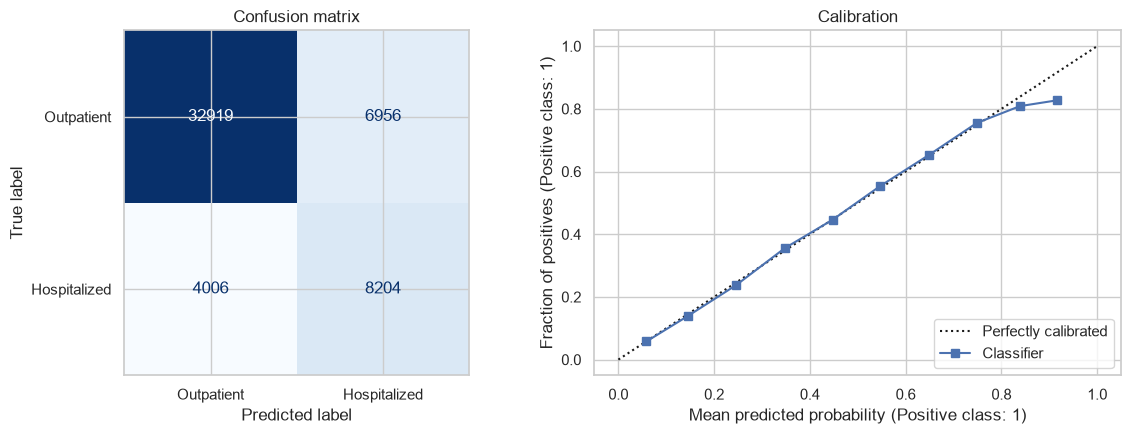

In [74]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = final_model.predict(X_test)   

print("Hold-out test performance ")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_proba):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_proba):.3f}")
print(f"F1       : {f1_score(y_test, test_pred):.3f}")
print(f"Precision: {precision_score(y_test, test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, test_pred):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title('Confusion matrix')
CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration')
plt.tight_layout(); plt.show()

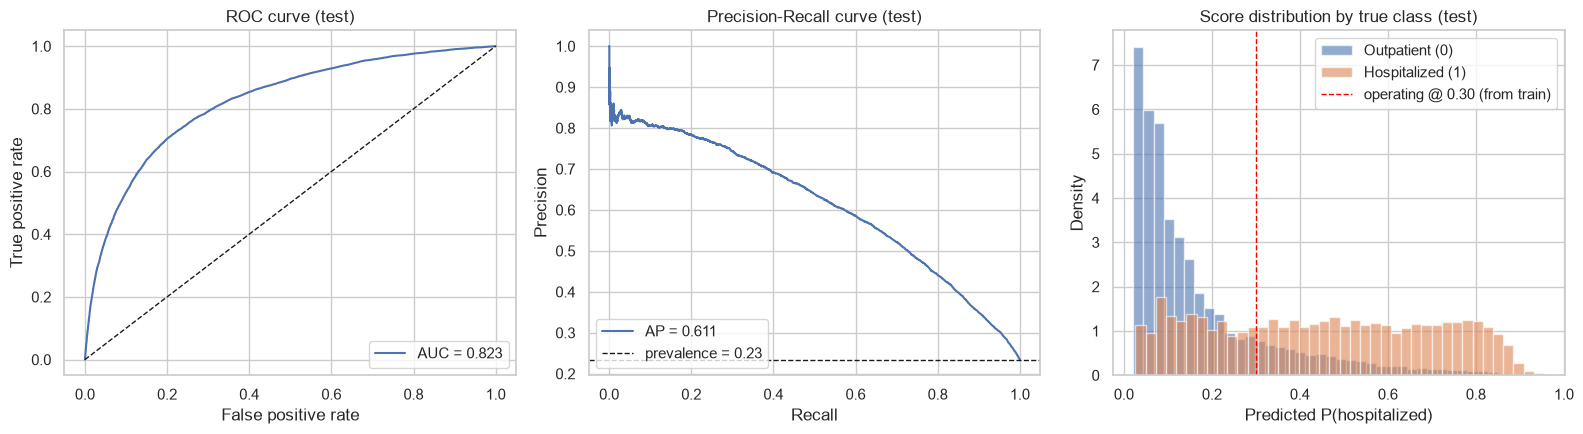

In [75]:
proba = final_model.predict_proba(X_test)[:, 1]   

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (test)"); axes[0].legend(loc="lower right")

# (2) Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, label=f"AP = {average_precision_score(y_test, proba):.3f}")
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (test)"); axes[1].legend(loc="lower left")

# (3) Predicted-probability distribution by true class
axes[2].hist(proba[y_test.to_numpy() == 0], bins=40, alpha=0.6, density=True, label="Outpatient (0)")
axes[2].hist(proba[y_test.to_numpy() == 1], bins=40, alpha=0.6, density=True, label="Hospitalized (1)")
axes[2].axvline(CHOSEN_THRESHOLD, color='red', ls='--', lw=1,
                label=f"operating @ {CHOSEN_THRESHOLD:.2f} (from train)")
axes[2].set_xlabel("Predicted P(hospitalized)"); axes[2].set_ylabel("Density")
axes[2].set_title("Score distribution by true class (test)"); axes[2].legend()

plt.tight_layout(); plt.show()

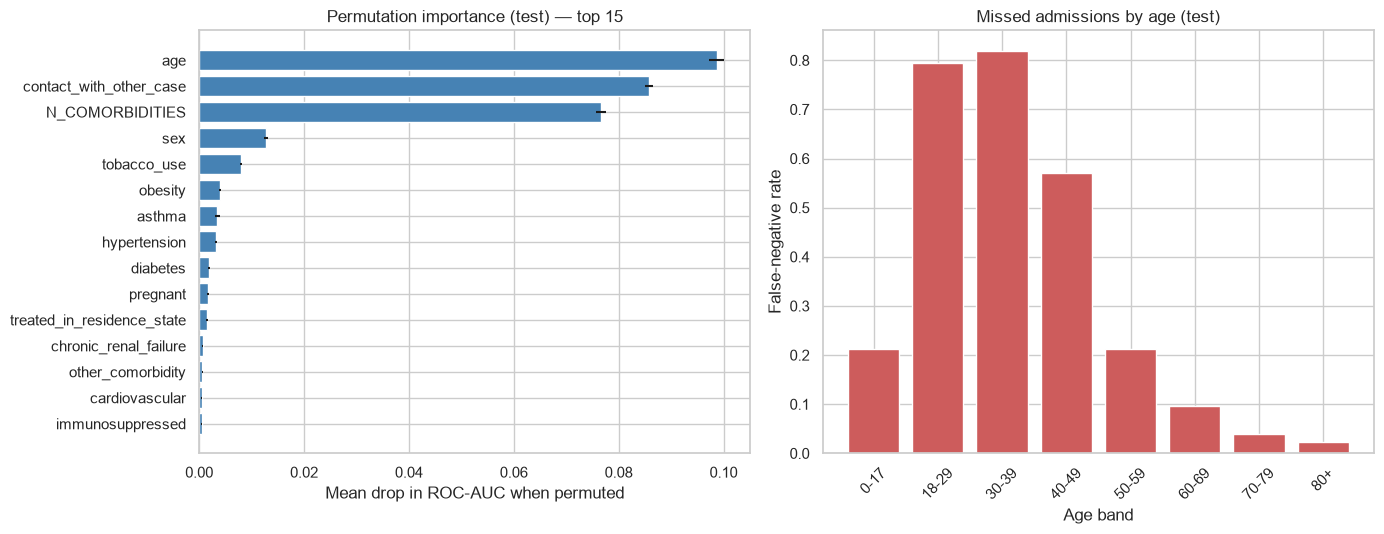

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (left) Permutation feature importance
rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(50000, len(X_test))
sub = rng.choice(len(X_test), size=n_pi, replace=False)
pi = permutation_importance(best_model, X_test.iloc[sub], y_test.iloc[sub],
                            scoring='roc_auc', n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values().tail(15)
axes[0].barh(imp.index, imp.values,
             xerr=pd.Series(pi.importances_std, index=X_test.columns).loc[imp.index],
             color='steelblue')
axes[0].set_xlabel("Mean drop in ROC-AUC when permuted")
axes[0].set_title("Permutation importance (test) — top 15")

# (right) False-negative rate by age band
tmp = pd.DataFrame({'age': X_test['age'].to_numpy(),
                    'y_true': y_test.to_numpy(), 'y_pred': test_pred})
tmp['age_band'] = pd.cut(tmp['age'], bins=age_bins, labels=age_labels, right=False)
pos = tmp[tmp['y_true'] == 1]
fn_rate = pos.groupby('age_band', observed=True)['y_pred'].apply(lambda s: (s == 0).mean())
axes[1].bar(fn_rate.index.astype(str), fn_rate.values, color='indianred')
axes[1].set_xlabel("Age band"); axes[1].set_ylabel("False-negative rate")
axes[1].set_title("Missed admissions by age (test)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


In [77]:
# Error per different feature (age,sex,# comorbidities)
err = X_test.copy()
err['y_true'] = y_test.values
err['y_pred'] = test_pred
err['age_band'] = pd.cut(err['age'], bins=age_bins, labels=age_labels, right=False)
err['n_comorb'] = err[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4).astype(int)


def group_report(col):
    def summarize(sub):
        pos = sub['y_true'] == 1
        false_neg = (pos & (sub['y_pred'] == 0)).sum()
        return pd.Series({
            'n': len(sub),
            'error_rate': 1 - (sub['y_true'] == sub['y_pred']).mean(),
            'false_neg_rate': false_neg / max(int(pos.sum()), 1),
        })
    return err.groupby(col, observed=True).apply(summarize, include_groups=False).round(3)


for col in ['age_band', 'sex', 'n_comorb']:
    print(f"\n=== Error by {col} ===")
    print(group_report(col))


=== Error by age_band ===
                n  error_rate  false_neg_rate
age_band                                     
0-17       2550.0       0.256           0.213
18-29      8822.0       0.094           0.794
30-39     12709.0       0.114           0.820
40-49     11453.0       0.224           0.571
50-59      8334.0       0.329           0.213
60-69      4660.0       0.347           0.097
70-79      2325.0       0.318           0.040
80+        1232.0       0.307           0.024

=== Error by sex ===
           n  error_rate  false_neg_rate
sex                                     
0    25555.0       0.176           0.391
1    26530.0       0.243           0.287

=== Error by n_comorb ===
                n  error_rate  false_neg_rate
n_comorb                                     
0         29232.0       0.158           0.556
1         13426.0       0.251           0.316
2          6037.0       0.312           0.142
3          2363.0       0.329           0.070
4          1027.0       

In [78]:
print("Library versions")
for m in [np, pd, sklearn, matplotlib, sns, plotly, optuna]:
    print(f"  {m.__name__}: {m.__version__}")

print(f"\nRANDOM_STATE = {RANDOM_STATE}")


Library versions
  numpy: 2.5.0
  pandas: 3.0.3
  sklearn: 1.9.0
  matplotlib: 3.11.0
  seaborn: 0.13.2
  plotly: 6.8.0
  optuna: 4.9.0

RANDOM_STATE = 42
